# Classification d'images à l'aide de réseaux de neurones convolutifs (CNN)

**Dataset utilisé :** CIFAR-10  
**Objectif :** Classer automatiquement des images parmi 10 catégories d'objets courants.  
**Problème :** Classification supervisée multiclasse sur images.

## 0. Installation et imports

In [ ]:
!pip install tensorflow matplotlib numpy scikit-learn seaborn Pillow tqdm --quiet

In [ ]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing import image   # ← ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

## 1. Définition du problème et du dataset

### 1.1 Contexte

La classification d'images est une tâche fondamentale en vision par ordinateur. Elle permet :
- La reconnaissance automatique d'objets dans des photos
- Le tri et l'indexation automatique d'images
- Une brique de base pour la détection et la segmentation d'objets

### 1.2 Dataset : CIFAR-10

Le **CIFAR-10** (Canadian Institute For Advanced Research) est un benchmark de référence pour la classification d'images :
- **10 classes** d'objets du quotidien
- **60 000 images** au total (50 000 train + 10 000 test)
- Images de **32×32 pixels** en couleur (RGB)
- Dataset **équilibré** : exactement 6 000 images par classe
- Téléchargement automatique via `keras.datasets.cifar10`

### 1.3 Noms des classes

In [ ]:
CLASS_NAMES = [
    'Avion', 'Voiture', 'Oiseau', 'Chat', 'Cerf',
    'Chien', 'Grenouille', 'Cheval', 'Bateau', 'Camion'
]

NUM_CLASSES = len(CLASS_NAMES)
print(f"Nombre de classes : {NUM_CLASSES}")
print("\nListe des classes :")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Classe {i:2d} : {name}")

Nombre de classes : 10

Liste des classes :
  Classe  0 : Avion
  Classe  1 : Voiture
  Classe  2 : Oiseau
  Classe  3 : Chat
  Classe  4 : Cerf
  Classe  5 : Chien
  Classe  6 : Grenouille
  Classe  7 : Cheval
  Classe  8 : Bateau
  Classe  9 : Camion


## 2. Chargement et préparation du dataset

### 2.1 Chargement du dataset CIFAR-10

In [ ]:
IMG_SIZE = 32
BATCH_SIZE = 64

print("Chargement du dataset CIFAR-10...")
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Normalisation [0, 255] → [0, 1]
X_train_full = X_train_full.astype(np.float32) / 255.0
X_test       = X_test.astype(np.float32)       / 255.0

# Les labels sont de forme (N, 1) → on aplatit en (N,)
y_train_full = y_train_full.flatten().astype(np.int32)
y_test       = y_test.flatten().astype(np.int32)

print("Dataset CIFAR-10 chargé avec succès.")

Chargement du dataset CIFAR-10...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Dataset CIFAR-10 chargé avec succès.


In [ ]:
print(f"Taille des images : {IMG_SIZE}x{IMG_SIZE}")
print(f"Taille des batches : {BATCH_SIZE}")

Taille des images : 32x32
Taille des batches : 64


In [ ]:
# Split train / validation (85% / 15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=42,
    stratify=y_train_full
)

print(f"\nFormes des données :")
print(f"  X_train : {X_train.shape}, y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape},   y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape},  y_test  : {y_test.shape}")
print(f"  Valeurs min/max pixels : [{X_train.min():.2f}, {X_train.max():.2f}]")


Formes des données :
  X_train : (42500, 32, 32, 3), y_train : (42500,)
  X_val   : (7500, 32, 32, 3),   y_val   : (7500,)
  X_test  : (10000, 32, 32, 3),  y_test  : (10000,)
  Valeurs min/max pixels : [0.00, 1.00]


### 2.2 Visualisation du dataset

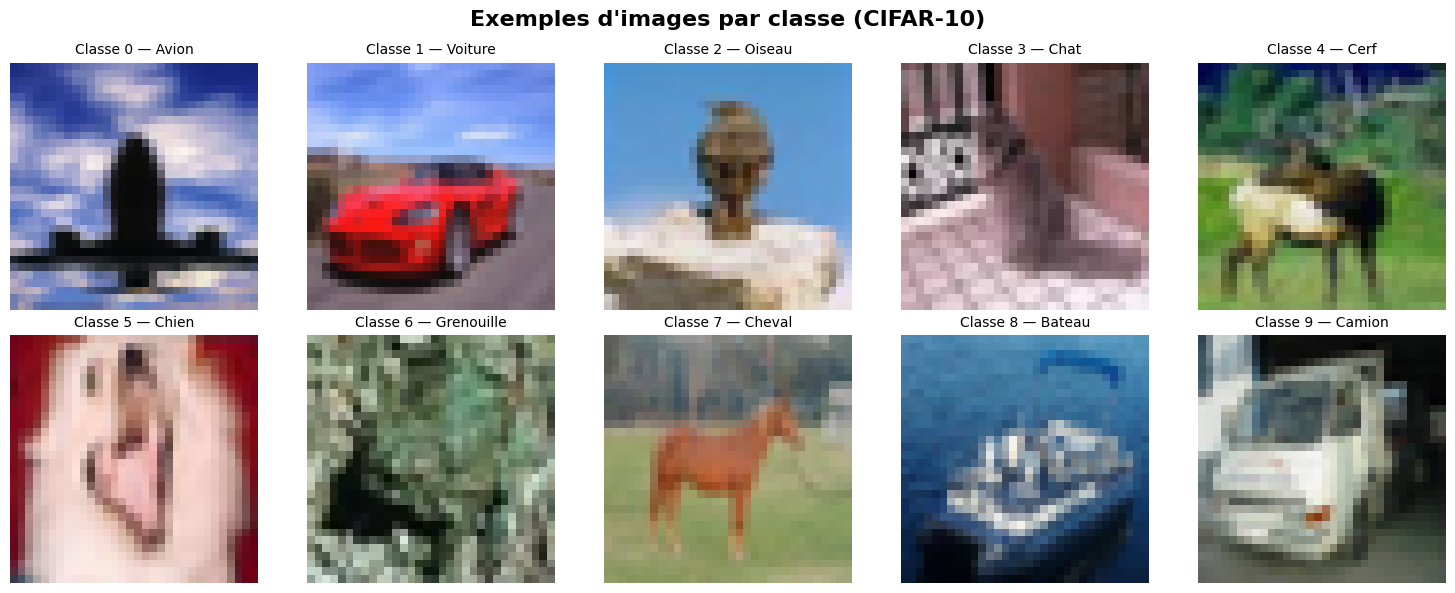

In [ ]:
# Affichage d'un exemple par classe
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Exemples d'images par classe (CIFAR-10)", fontsize=16, fontweight='bold')

for cls in range(NUM_CLASSES):
    ax = axes[cls // 5, cls % 5]
    idx = np.where(y_train == cls)[0][0]
    ax.imshow(X_train[idx])
    ax.set_title(f'Classe {cls} — {CLASS_NAMES[cls]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('exemples_dataset.png', dpi=100, bbox_inches='tight')
plt.show()

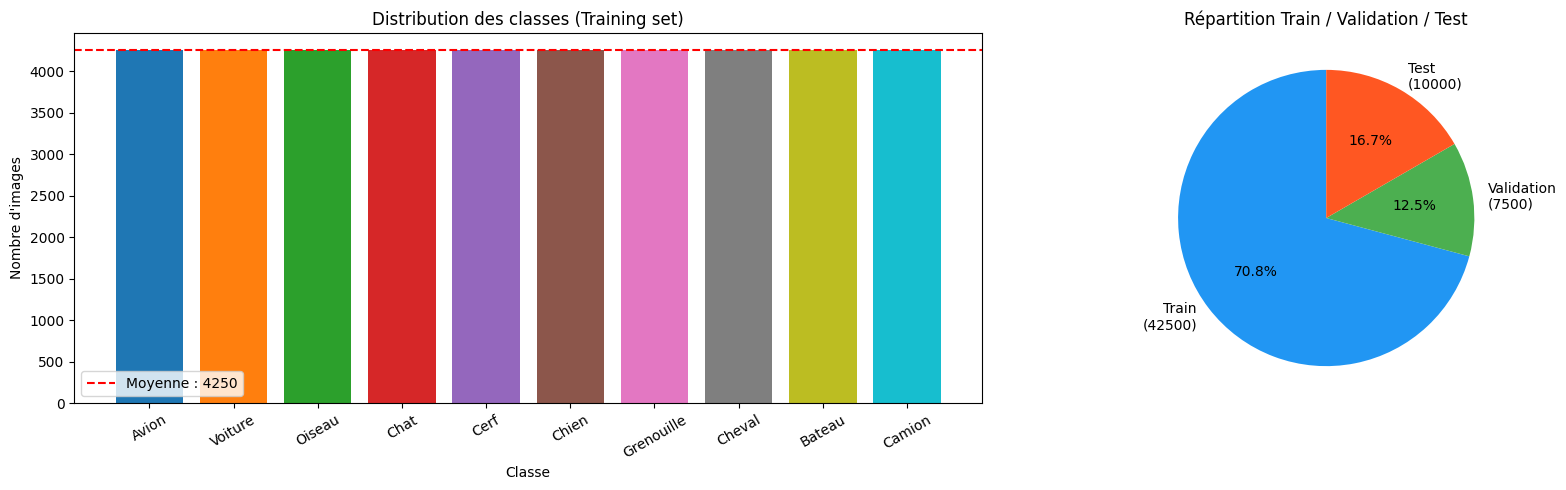

Classe la plus représentée  : 4250 images (classe 0 — Avion)
Classe la moins représentée : 4250 images (classe 0 — Avion)
Ratio max/min : 1.0x → Dataset équilibré


In [ ]:
# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

class_counts = np.bincount(y_train, minlength=NUM_CLASSES)
tab_colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
axes[0].bar(CLASS_NAMES, class_counts, color=tab_colors)
axes[0].set_xlabel('Classe')
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title('Distribution des classes (Training set)')
axes[0].axhline(y=class_counts.mean(), color='red', linestyle='--',
                label=f'Moyenne : {class_counts.mean():.0f}')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

sizes  = [len(X_train), len(X_val), len(X_test)]
labels = [f'Train\n({sizes[0]})', f'Validation\n({sizes[1]})', f'Test\n({sizes[2]})']
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#2196F3', '#4CAF50', '#FF5722'])
axes[1].set_title('Répartition Train / Validation / Test')

plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Classe la plus représentée  : {class_counts.max()} images "
      f"(classe {class_counts.argmax()} — {CLASS_NAMES[class_counts.argmax()]})")
print(f"Classe la moins représentée : {class_counts.min()} images "
      f"(classe {class_counts.argmin()} — {CLASS_NAMES[class_counts.argmin()]})")
print(f"Ratio max/min : {class_counts.max()/class_counts.min():.1f}x → Dataset équilibré")

### 2.3 Récapitulatif du prétraitement

| Étape | Traitement | Justification |
|---|---|---|
| Chargement | `keras.datasets.cifar10` | Téléchargement automatique, format prêt à l'emploi |
| Normalisation | division par 255 → [0, 1] | Stabilise la convergence |
| Encodage labels | entiers aplatis (0–9) | Compatible avec `sparse_categorical_crossentropy` |
| Split | 85% train / 15% val | Bonne estimation de la généralisation |

## 3. Fonctions utilitaires

In [ ]:
def plot_history(history, title='', ax1=None, ax2=None, label='', color='blue'):
    """Affiche les courbes accuracy et loss d'un historique d'entraînement."""
    standalone = ax1 is None
    if standalone:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        fig.suptitle(title, fontsize=13, fontweight='bold')

    epochs = range(1, len(history['accuracy']) + 1)

    ax1.plot(epochs, history['accuracy'],     '-',  color=color, label=f'{label} Train' if label else 'Train')
    ax1.plot(epochs, history['val_accuracy'], '--', color=color, label=f'{label} Val'   if label else 'Validation')
    ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy'); ax1.set_title('Accuracy')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history['loss'],     '-',  color=color, label=f'{label} Train' if label else 'Train')
    ax2.plot(epochs, history['val_loss'], '--', color=color, label=f'{label} Val'   if label else 'Validation')
    ax2.set_xlabel('Époque'); ax2.set_ylabel('Loss'); ax2.set_title('Loss')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    if standalone:
        plt.tight_layout()
        plt.savefig(f'history_{title.replace(" ", "_")}.png', dpi=100, bbox_inches='tight')
        plt.show()


def evaluate_model(model, X_test, y_test, model_name=''):
    """Évalue un modèle et retourne les métriques."""
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"[{model_name}] Test accuracy : {acc:.4f} | Test loss : {loss:.4f}")
    return loss, acc


# Stockage des résultats
results   = {}
histories = {}
COLORS    = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
print("Fonctions utilitaires définies.")

Fonctions utilitaires définies.


## 4. Modèle 1 — CNN de base (Baseline)

Architecture simple pour établir une performance initiale.  
Pas d'augmentation : les données sont fournies telles quelles au modèle.

In [ ]:
def build_cnn_base(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """CNN de base : 2 blocs Conv+Pool, 1 Dense caché."""
    model = Sequential([
        # Bloc 1
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(img_size, img_size, 3)),
        MaxPooling2D((2, 2)),

        # Bloc 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Classifier
        Flatten(),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='CNN_Base')

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_base = build_cnn_base()
model_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Entraînement du CNN de base...")
start = time.time()

history_base = model_base.fit(
    X_train, y_train,
    epochs=20,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

time_base = time.time() - start
print(f"Temps d'entraînement : {time_base:.1f} secondes")
histories['CNN_Base'] = history_base.history

Entraînement du CNN de base...
Epoch 1/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4623 - loss: 1.4952 - val_accuracy: 0.5079 - val_loss: 1.3732
Epoch 2/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6017 - loss: 1.1361 - val_accuracy: 0.5891 - val_loss: 1.1496
Epoch 3/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6564 - loss: 0.9797 - val_accuracy: 0.6337 - val_loss: 1.0394
Epoch 4/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6948 - loss: 0.8784 - val_accuracy: 0.6543 - val_loss: 0.9842
Epoch 5/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7232 - loss: 0.8008 - val_accuracy: 0.6684 - val_loss: 0.9500
Epoch 6/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7468 - loss: 0.7335 - val_accuracy: 0.6728 - val_loss: 0.9520
Epoch 7/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7692 - loss: 0.6699 - val_accuracy: 0.6717 - val_loss: 0.9727
Epoch 8/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7897 - 

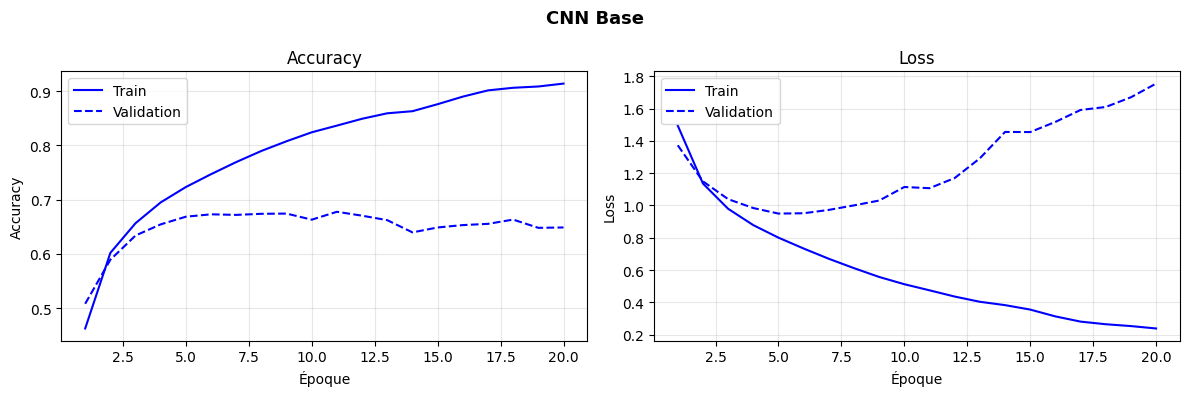

[CNN_Base] Test accuracy : 0.6553 | Test loss : 1.7193

Analyse overfitting :
  Accuracy train final : 0.9139
  Accuracy val final   : 0.6485
  Écart train/val      : 0.2654 → Overfitting significatif


In [ ]:
plot_history(histories['CNN_Base'], title='CNN Base')

loss_base, acc_base = evaluate_model(model_base, X_test, y_test, 'CNN_Base')
results['CNN_Base'] = {
    'val_acc'    : max(histories['CNN_Base']['val_accuracy']),
    'test_acc'   : acc_base,
    'test_loss'  : loss_base,
    'train_time' : time_base,
    'params'     : model_base.count_params()
}

train_acc_final = histories['CNN_Base']['accuracy'][-1]
val_acc_final   = histories['CNN_Base']['val_accuracy'][-1]
gap = train_acc_final - val_acc_final
print(f"\nAnalyse overfitting :")
print(f"  Accuracy train final : {train_acc_final:.4f}")
print(f"  Accuracy val final   : {val_acc_final:.4f}")
print(f"  Écart train/val      : {gap:.4f} → {'Overfitting significatif' if gap > 0.1 else 'Overfitting modéré'}")

### 4.1 Analyse de l'overfitting

L'overfitting se manifeste quand :
- L'accuracy d'entraînement continue d'augmenter
- L'accuracy de validation stagne ou régresse
- La loss de validation remonte

**Causes possibles dans ce contexte :**
- Classes visuellement proches (ex. chat/chien, voiture/camion)
- Images 32×32 peu détaillées, rendant la tâche difficile
- Aucune régularisation ni augmentation dans ce modèle

In [ ]:
model_base.save('cnn_base.keras')
with open('history_cnn_base.pkl', 'wb') as f:
    pickle.dump(histories['CNN_Base'], f)
print("Modèle 1 sauvegardé : cnn_base.keras + history_cnn_base.pkl")

Modèle 1 sauvegardé : cnn_base.keras + history_cnn_base.pkl


## 5. Modèle 2 — CNN + Dropout

Ajout de couches **Dropout** pour réduire l'overfitting en forçant la redondance des représentations.  
Toujours sans augmentation de données.

In [ ]:
def build_cnn_dropout(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """CNN avec Dropout après chaque bloc et avant la sortie."""
    model = Sequential([
        # Bloc 1
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(img_size, img_size, 3)),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Bloc 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Classifier
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ], name='CNN_Dropout')

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_dropout = build_cnn_dropout()
model_dropout.summary()

Model: "CNN_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Entraînement du CNN + Dropout...
Epoch 1/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.3376 - loss: 1.7912 - val_accuracy: 0.4752 - val_loss: 1.4412
Epoch 2/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4606 - loss: 1.4835 - val_accuracy: 0.5511 - val_loss: 1.2635
Epoch 3/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5041 - loss: 1.3698 - val_accuracy: 0.5540 - val_loss: 1.2446
Epoch 4/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5322 - loss: 1.2957 - val_accuracy: 0.6083 - val_loss: 1.1075
Epoch 5/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5547 - loss: 1.2455 - val_accuracy: 0.6148 - val_loss: 1.0942
Epoch 6/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5731 - loss: 1.1928 - val_accuracy: 0.6436 - val_loss: 1.0308
Epoch 7/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5858 - loss: 1.1610 - val_accuracy: 0.6531 - val_loss: 0.9881
Epoch 8/20
665/665 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.596

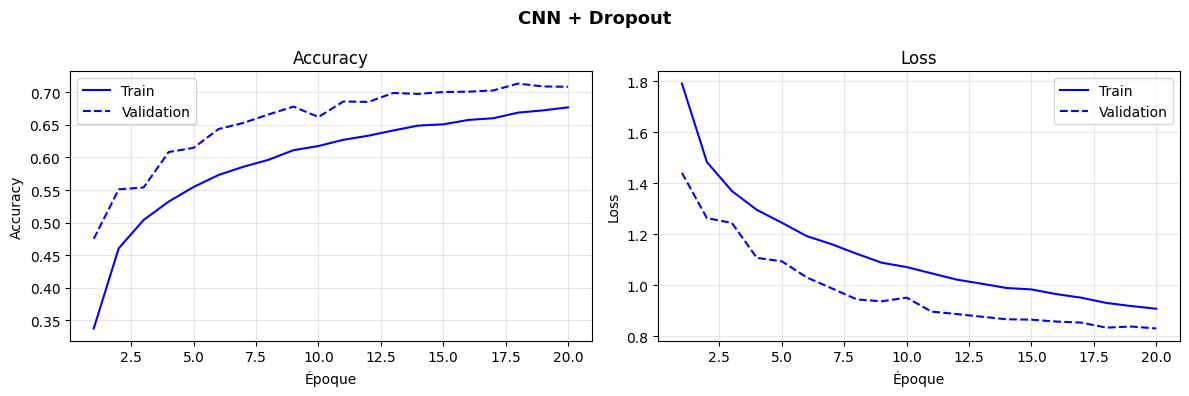

[CNN_Dropout] Test accuracy : 0.7122 | Test loss : 0.8413


In [ ]:
print("Entraînement du CNN + Dropout...")
start = time.time()

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=20,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)

time_dropout = time.time() - start
print(f"Temps d'entraînement : {time_dropout:.1f} secondes")

histories['CNN_Dropout'] = history_dropout.history
plot_history(histories['CNN_Dropout'], title='CNN + Dropout')

loss_dropout, acc_dropout = evaluate_model(model_dropout, X_test, y_test, 'CNN_Dropout')
results['CNN_Dropout'] = {
    'val_acc'    : max(histories['CNN_Dropout']['val_accuracy']),
    'test_acc'   : acc_dropout,
    'test_loss'  : loss_dropout,
    'train_time' : time_dropout,
    'params'     : model_dropout.count_params()
}

In [ ]:
model_dropout.save('cnn_dropout.keras')
with open('history_cnn_dropout.pkl', 'wb') as f:
    pickle.dump(histories['CNN_Dropout'], f)
print("Modèle 2 sauvegardé : cnn_dropout.keras + history_cnn_dropout.pkl")

Modèle 2 sauvegardé : cnn_dropout.keras + history_cnn_dropout.pkl


## 6. Modèle 3 — CNN + Data Augmentation (ImageDataGenerator)

L'augmentation de données génère à la volée des variantes des images d'entraînement via **`ImageDataGenerator`**.

**Principe clé :**
- Un `train_datagen` augmenté pour l'entraînement
- Un `val_datagen` **sans aucune augmentation** pour la validation et le test
- Les paramètres sont **calibrés pour des images 32×32** : des valeurs trop fortes (ex. `rotation_range=40`) détruisent l'information sur de si petites images


In [1]:
# ── Générateur TRAIN : avec augmentation ───────────────
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = image.ImageDataGenerator()

print('Generateurs configures.')
print('  train_datagen : augmentation active (rotation, shift, shear, zoom, flip)')
print('  val_datagen   : aucune transformation (validation et test bruts)')


NameError: name 'image' is not defined

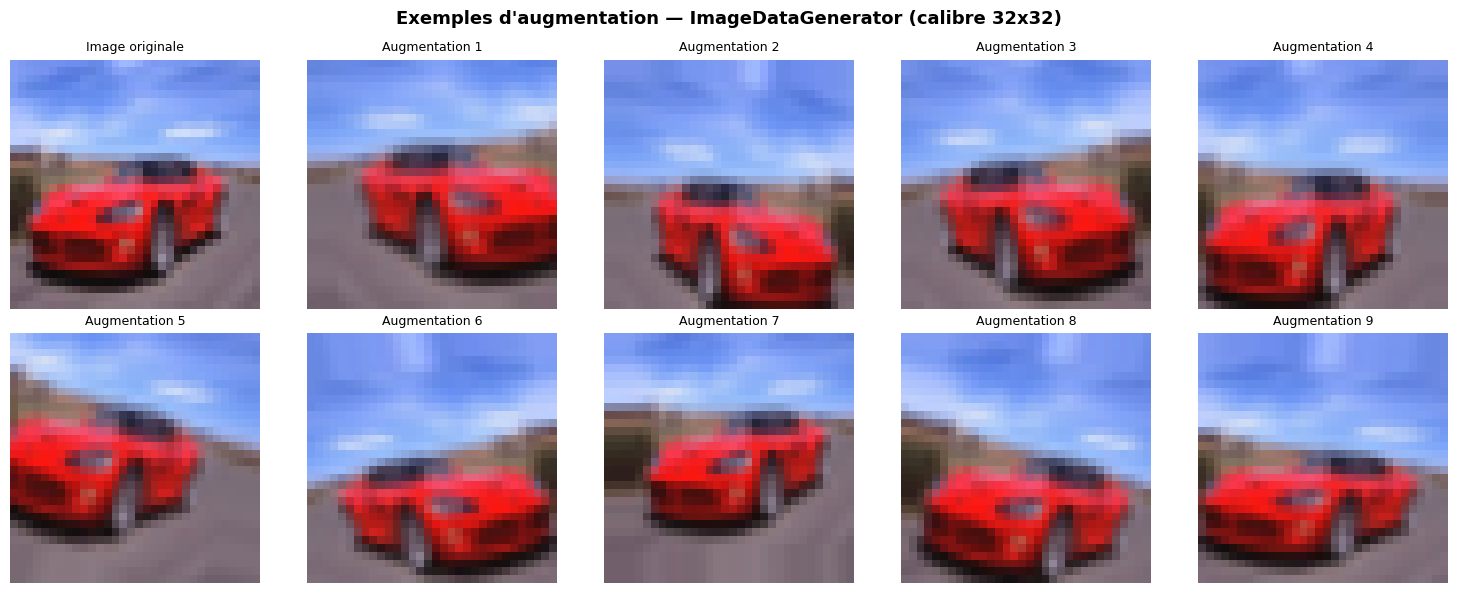

Transformations appliquees (calibrees pour 32x32 px) :
  - rotation_range=15      : rotation +-15 (TD4 utilisait 40)
  - width_shift_range=0.1  : decalage horizontal +-10%
  - height_shift_range=0.1 : decalage vertical +-10%
  - shear_range=0.1        : cisaillement +-0.1 rad
  - zoom_range=0.1         : zoom +-10%
  - horizontal_flip=True   : retournement horizontal aleatoire
  - fill_mode='nearest'    : remplissage par pixel voisin le plus proche


In [ ]:
# ── Visualisation des augmentations sur un exemple ───────────────────────────
sample_img = X_train[0:1]   # forme (1, 32, 32, 3)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Exemples d'augmentation — ImageDataGenerator (calibre 32x32)",
             fontsize=13, fontweight='bold')

axes[0, 0].imshow(sample_img[0])
axes[0, 0].set_title('Image originale', fontsize=9)
axes[0, 0].axis('off')

aug_iter = train_datagen.flow(sample_img, batch_size=1)
for i in range(1, 10):
    aug_img = next(aug_iter)[0]
    aug_img = np.clip(aug_img, 0, 1)
    axes[i // 5, i % 5].imshow(aug_img)
    axes[i // 5, i % 5].set_title(f'Augmentation {i}', fontsize=9)
    axes[i // 5, i % 5].axis('off')

plt.tight_layout()
plt.savefig('data_augmentation_exemples.png', dpi=100, bbox_inches='tight')
plt.show()

print('Transformations appliquees (calibrees pour 32x32 px) :')
print('  - rotation_range=15      : rotation +-15')
print('  - width_shift_range=0.1  : decalage horizontal +-10%')
print('  - height_shift_range=0.1 : decalage vertical +-10%')
print('  - shear_range=0.1        : cisaillement +-0.1 rad')
print('  - zoom_range=0.1         : zoom +-10%')
print('  - horizontal_flip=True   : retournement horizontal aleatoire')
print("  - fill_mode='nearest'    : remplissage par pixel voisin le plus proche")


In [ ]:
def build_cnn_augmented(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    model = Sequential([
        # Bloc 1 : 32 filtres
        Conv2D(32, (3, 3), activation='relu', padding='same',
               input_shape=(img_size, img_size, 3)),
        MaxPooling2D((2, 2)),

        # Bloc 2 : 64 filtres
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Bloc 3 : 128 filtres (pas de MaxPooling : on garde 4x4)
        Conv2D(128, (3, 3), activation='relu', padding='same'),

        # Classifier — Dropout 0.5 avant le Dense
        Flatten(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dense(num_classes, activation='softmax')
    ], name='CNN_Augmented')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_aug = build_cnn_augmented()
model_aug.summary()


Model: "CNN_Augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,226 (8.37 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement du CNN + Data Augmentation (ImageDataGenerator)...
Epoch 1/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.6616 - loss: 0.9571 - val_accuracy: 0.6844 - val_loss: 0.8924
Epoch 2/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.6691 - loss: 0.9414 - val_accuracy: 0.6749 - val_loss: 0.9455
Epoch 3/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 27s 41ms/step - accuracy: 0.6725 - loss: 0.9325 - val_accuracy: 0.6852 - val_loss: 0.8912
Epoch 4/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.6750 - loss: 0.9197 - val_accuracy: 0.6723 - val_loss: 0.9366
Epoch 5/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 42ms/step - accuracy: 0.6808 - loss: 0.9073 - val_accuracy: 0.7048 - val_loss: 0.8405
Epoch 6/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6834 - loss: 0.8989 - val_accuracy: 0.7161 - val_loss: 0.8137
Epoch 7/50
665/665 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.6895 - loss: 0.8817 - val_accuracy: 0.7075 - val_loss: 0.8272
Epoch 8/50
665/665 ━━━━━━━

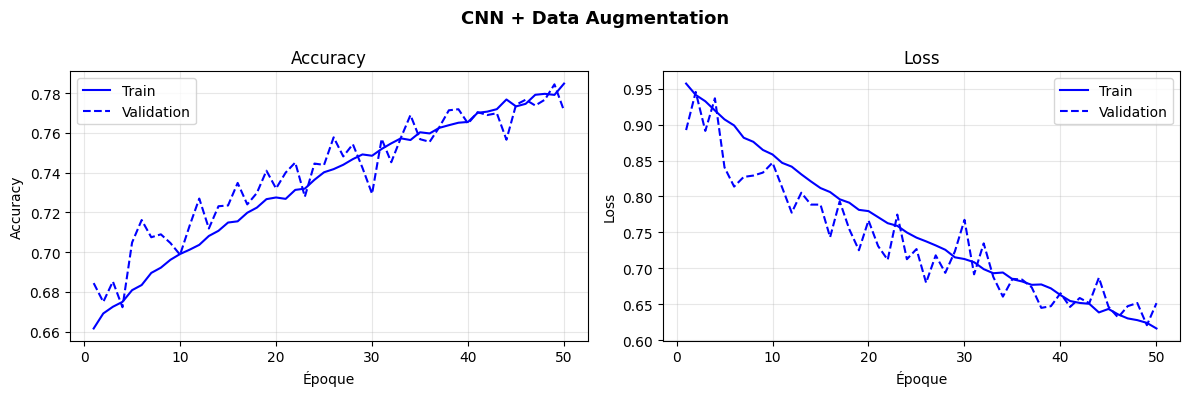

[CNN_Augmented] Test accuracy : 0.7809 | Test loss : 0.6321


In [ ]:
print('Entrainement du CNN + Data Augmentation (ImageDataGenerator)...')
start = time.time()


# train_datagen.flow() genere des batches augmentes a la volee
# val est passee en numpy brut — aucune augmentation
history_aug = model_aug.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=1
)

time_aug = time.time() - start
print(f"Temps d'entrainement : {time_aug:.1f} secondes")

histories['CNN_Augmented'] = history_aug.history
plot_history(histories['CNN_Augmented'], title='CNN + Data Augmentation')

loss_aug, acc_aug = evaluate_model(model_aug, X_test, y_test, 'CNN_Augmented')
results['CNN_Augmented'] = {
    'val_acc'    : max(histories['CNN_Augmented']['val_accuracy']),
    'test_acc'   : acc_aug,
    'test_loss'  : loss_aug,
    'train_time' : time_aug,
    'params'     : model_aug.count_params()
}


In [ ]:
model_aug.save('cnn_augmented.keras')
with open('history_cnn_augmented.pkl', 'wb') as f:
    pickle.dump(histories['CNN_Augmented'], f)
print("Modèle 3 sauvegardé : cnn_augmented.keras + history_cnn_augmented.pkl")

Modèle 3 sauvegardé : cnn_augmented.keras + history_cnn_augmented.pkl


## 7. Modèle 4 — Bonus CNN avec ResNet

  
Reutilise le **meme `train_datagen`** defini a la section 6.  
Modele le plus complet.


In [ ]:
from tensorflow.keras import Model, Input
from tensorflow.keras.optimizers import AdamW
import math


# ── Bloc résiduel ─────────────────────────────────────────────────────────────
def residual_block(x, filters, stride=1):
    """Bloc résiduel standard : Conv-BN-ReLU-Conv-BN + skip connection.

    Si le nombre de filtres ou le stride change, la skip connection
    est adaptée par une Conv 1x1 pour correspondre aux dimensions.
    """
    shortcut = x

    # Chemin principal
    x = layers.Conv2D(filters, 3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Skip connection : adapter si dimensions différentes
    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


# ── Cosine Decay avec Warmup ──────────────────────────────────────────────────
class WarmupCosineDecay(keras.callbacks.Callback):
    """Scheduler : montée linéaire (warmup) puis descente cosinus du LR.

    Paramètres :
    - warmup_epochs : nombre d'époques de montée progressive
    - total_epochs  : nombre total d'époques prévu
    - lr_max        : LR cible après le warmup
    - lr_min        : LR minimum en fin de cosine decay
    """
    def __init__(self, warmup_epochs, total_epochs, lr_max=1e-3, lr_min=1e-6):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.lr_max        = lr_max
        self.lr_min        = lr_min

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            # Phase warmup : montée linéaire de 0 → lr_max
            lr = self.lr_max * (epoch + 1) / self.warmup_epochs
        else:
            # Phase cosine decay : lr_max → lr_min
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + math.cos(math.pi * progress))
        self.model.optimizer.learning_rate.assign(lr)

    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        print(f'  LR = {lr:.2e}')


# ── Architecture ResNet custom ────────────────────────────────────────────────
def build_resnet_ultimate(num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """ResNet custom pour CIFAR-10 (32×32).

    Structure :
      Stem       : Conv 3x3, 32 filtres
      Stage 1    : 2x ResBlock(32)          — sortie 32x32
      Stage 2    : 2x ResBlock(64, stride2) — sortie 16x16
      Stage 3    : 2x ResBlock(128, stride2)— sortie 8x8
      Stage 4    : 2x ResBlock(256, stride2)— sortie 4x4
      Head       : GlobalAvgPool + Dropout(0.4) + Dense(10)

    Optimiseur : AdamW (weight_decay=1e-4)
    Scheduler  : Warmup (5 ep) + Cosine Decay
    """
    inputs = Input(shape=(img_size, img_size, 3))

    # Stem : première conv sans réduire la résolution
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Stage 1 : 32 filtres, résolution 32×32
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Stage 2 : 64 filtres, résolution 16×16
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64)

    # Stage 3 : 128 filtres, résolution 8×8
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128)

    # Stage 4 : 256 filtres, résolution 4×4
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='ResNet_Ultimate')

    model.compile(
        optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_deep = build_resnet_ultimate()
model_deep.summary()


Model: "ResNet_Ultimate"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_57 (Conv2D)  │ (None, 32, 32,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_57[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_39       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_58 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_39[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_58[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_40       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_59 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_40[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_59[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_39[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_41       │ (None, 32, 32,    │          0 │ add_18[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_60 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_41[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_60[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_61 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_42[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_61[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 2,802,410 (10.69 MB)

 Trainable params: 2,797,610 (10.67 MB)

 Non-trainable params: 4,800 (18.75 KB)

Entrainement ResNet Ultimate + Warmup Cosine Decay...
Epoch 1/80
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5047 - loss: 1.3849  LR = 2.00e-04
665/665 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.5266 - loss: 1.3231 - val_accuracy: 0.5152 - val_loss: 1.6251
Epoch 2/80
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5611 - loss: 1.2408  LR = 4.00e-04
665/665 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.5841 - loss: 1.1758 - val_accuracy: 0.5943 - val_loss: 1.1222
Epoch 3/80
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6324 - loss: 1.0466  LR = 6.00e-04
665/665 ━━━━━━━━━━━━━━━━━━━━ 34s 51ms/step - accuracy: 0.6493 - loss: 1.0037 - val_accuracy: 0.6877 - val_loss: 0.9066
Epoch 4/80
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.6838 - loss: 0.9158  LR = 8.00e-04
665/665 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.6924 - loss: 0.8850 - val_accuracy: 0.6296 - val_loss: 1.1435
Epoch 5/80
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accurac

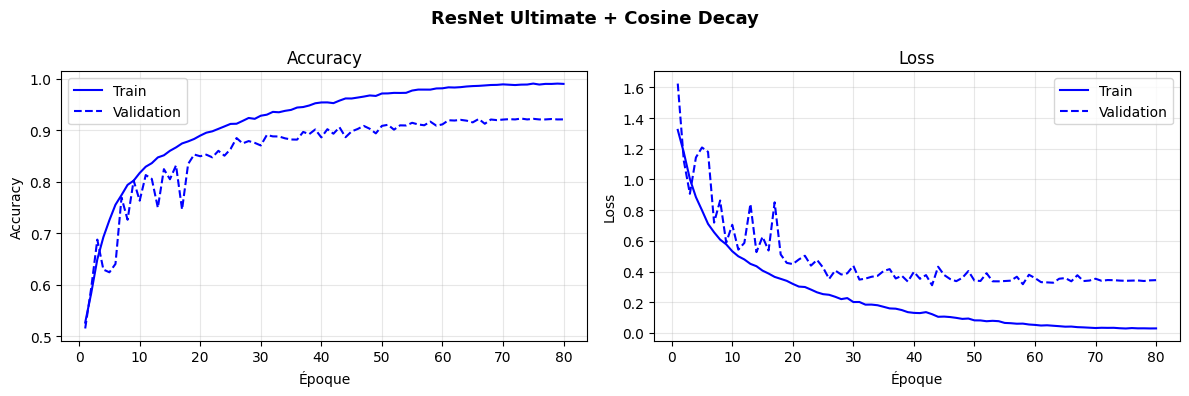

[CNN_Deep] Test accuracy : 0.9155 | Test loss : 0.3815


In [ ]:
TOTAL_EPOCHS  = 80
WARMUP_EPOCHS = 5

callbacks_deep = [
    WarmupCosineDecay(
        warmup_epochs=WARMUP_EPOCHS,
        total_epochs=TOTAL_EPOCHS,
        lr_max=1e-3,
        lr_min=1e-6
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,               # patience élevée : le cosine decay explore plus longtemps
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet_ultimate.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print('Entrainement ResNet Ultimate + Warmup Cosine Decay...')
start = time.time()

# Reutilisation du train_datagen defini section 6
history_deep = model_deep.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    epochs=TOTAL_EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=callbacks_deep,
    verbose=1
)

time_deep = time.time() - start
print(f"Arret a l'epoque {len(history_deep.history['loss'])} / {TOTAL_EPOCHS}")
print(f"Temps d'entrainement : {time_deep:.1f} secondes")

histories['CNN_Deep'] = history_deep.history
plot_history(histories['CNN_Deep'], title='ResNet Ultimate + Cosine Decay')

loss_deep, acc_deep = evaluate_model(model_deep, X_test, y_test, 'CNN_Deep')
results['CNN_Deep'] = {
    'val_acc'    : max(histories['CNN_Deep']['val_accuracy']),
    'test_acc'   : acc_deep,
    'test_loss'  : loss_deep,
    'train_time' : time_deep,
    'params'     : model_deep.count_params()
}


In [ ]:
model_deep.save('cnn_deep.keras')
with open('history_cnn_deep.pkl', 'wb') as f:
    pickle.dump(histories['CNN_Deep'], f)
print("Modèle 4 sauvegardé : cnn_deep.keras + history_cnn_deep.pkl")

Modèle 4 sauvegardé : cnn_deep.keras + history_cnn_deep.pkl


## 8. Comparaison finale des modèles

In [ ]:
print("=" * 85)
print(f"{'Modèle':<20} {'Val Acc Max':>11} {'Test Acc':>9} {'Test Loss':>10} {'Temps (s)':>10} {'Params':>12}")
print("=" * 85)

for name, r in results.items():
    print(f"{name:<20} {r['val_acc']:>10.4f}  {r['test_acc']:>9.4f}  "
          f"{r['test_loss']:>9.4f}  {r['train_time']:>9.1f}  {r['params']:>12,}")

print("=" * 85)
best_model_name = max(results, key=lambda x: results[x]['test_acc'])
print(f"\n→ Meilleur modèle (test accuracy) : {best_model_name} "
      f"({results[best_model_name]['test_acc']:.4f})")

Modèle               Val Acc Max  Test Acc  Test Loss  Temps (s)       Params
CNN_Base                 0.6775     0.6553     1.7193       70.0       545,098
CNN_Dropout              0.7133     0.7122     0.8413       76.3       545,098
CNN_Augmented            0.7844     0.7809     0.6321     1464.7     2,193,226
CNN_Deep                 0.9228     0.9155     0.3815     2676.9     2,802,410

→ Meilleur modèle (test accuracy) : CNN_Deep (0.9155)


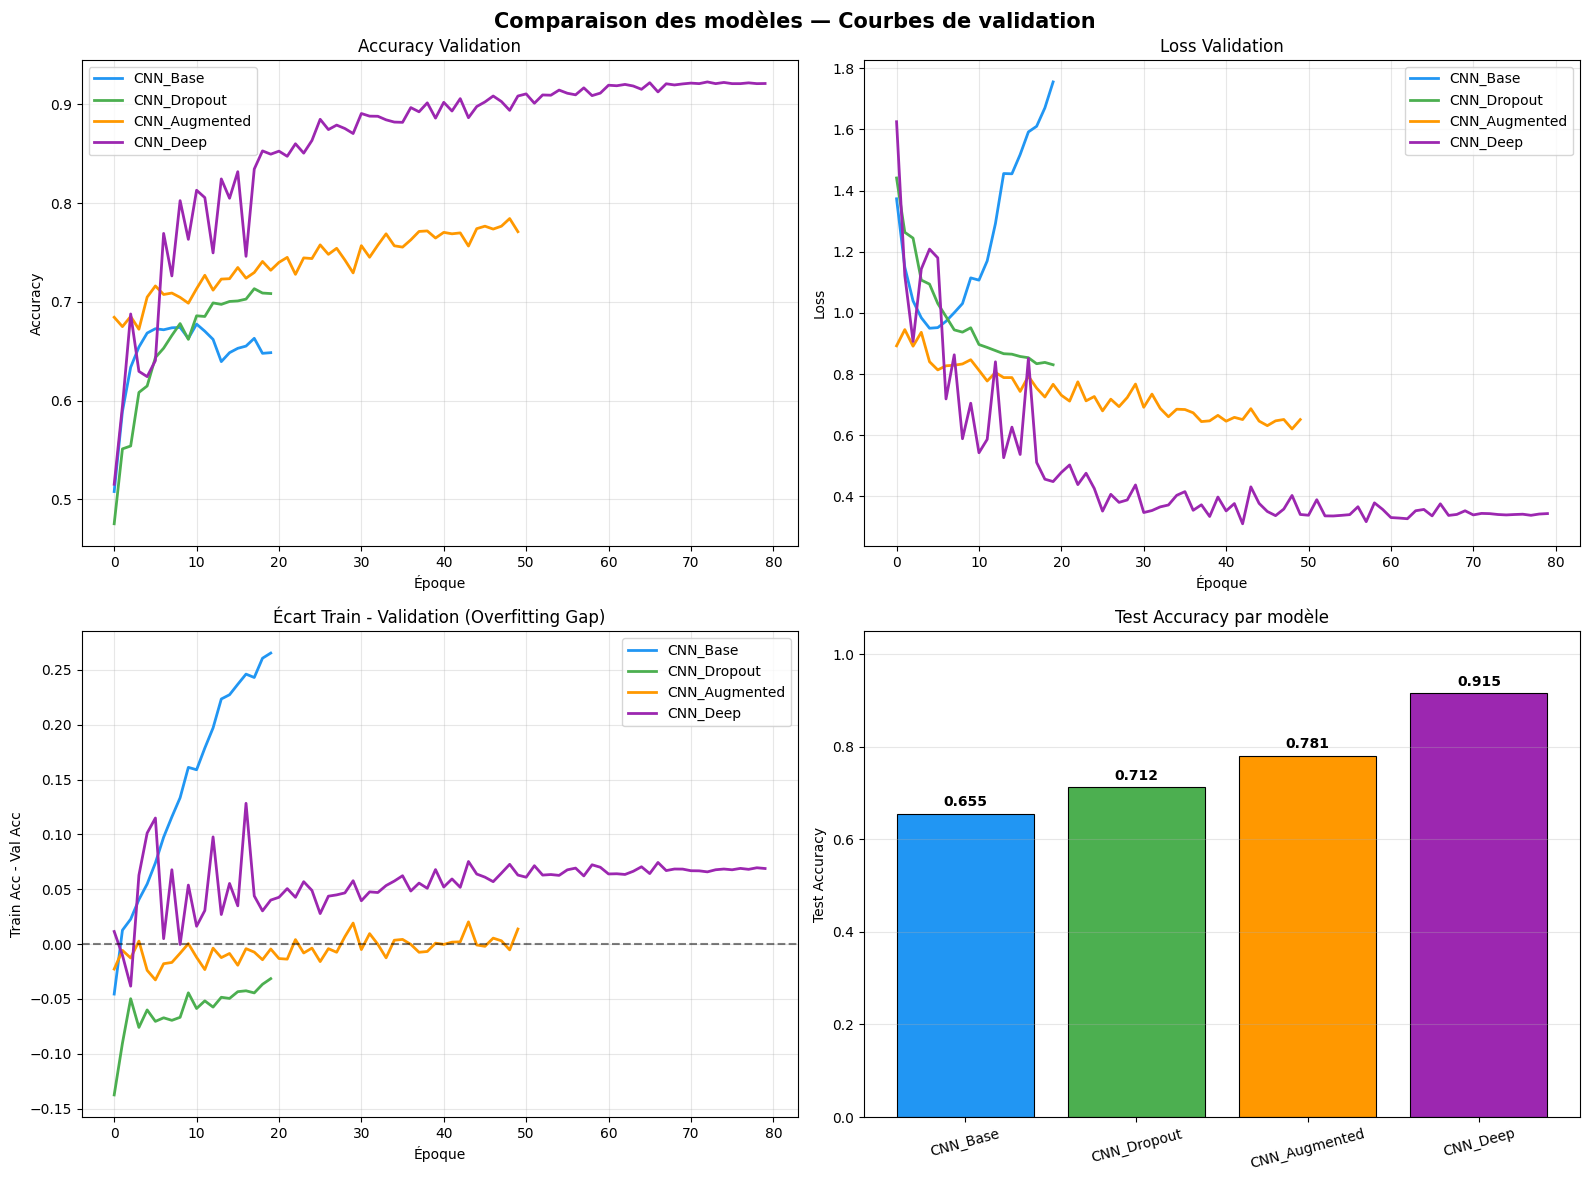

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison des modèles — Courbes de validation', fontsize=15, fontweight='bold')

# Accuracy validation
ax = axes[0, 0]
for i, (name, h) in enumerate(histories.items()):
    ax.plot(h['val_accuracy'], color=COLORS[i], label=name, linewidth=2)
ax.set_title('Accuracy Validation'); ax.set_xlabel('Époque'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)

# Loss validation
ax = axes[0, 1]
for i, (name, h) in enumerate(histories.items()):
    ax.plot(h['val_loss'], color=COLORS[i], label=name, linewidth=2)
ax.set_title('Loss Validation'); ax.set_xlabel('Époque'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# Overfitting gap
ax = axes[1, 0]
for i, (name, h) in enumerate(histories.items()):
    gap = np.array(h['accuracy']) - np.array(h['val_accuracy'])
    ax.plot(gap, color=COLORS[i], label=name, linewidth=2)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Écart Train - Validation (Overfitting Gap)')
ax.set_xlabel('Époque'); ax.set_ylabel('Train Acc - Val Acc')
ax.legend(); ax.grid(True, alpha=0.3)

# Barres test accuracy
ax = axes[1, 1]
names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
bars = ax.bar(names, test_accs, color=COLORS[:len(names)], edgecolor='black', linewidth=0.8)
ax.set_title('Test Accuracy par modèle'); ax.set_ylabel('Test Accuracy'); ax.set_ylim(0, 1.05)
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')
ax.tick_params(axis='x', rotation=15); ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=100, bbox_inches='tight')
plt.show()

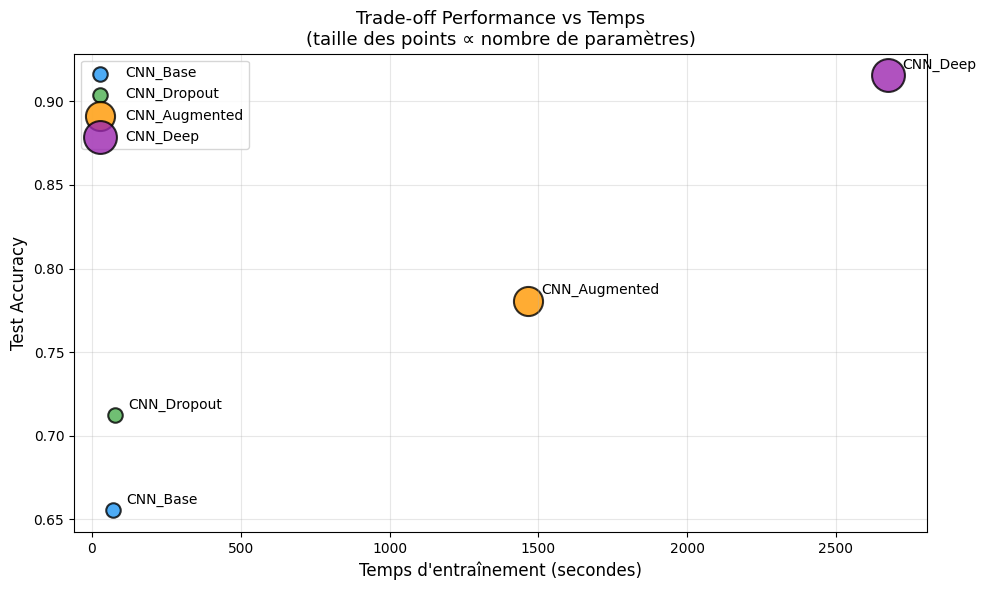

In [ ]:
# Trade-off Performance vs Temps
fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, r) in enumerate(results.items()):
    ax.scatter(r['train_time'], r['test_acc'], s=r['params']/5000,
               color=COLORS[i], label=name, alpha=0.8, edgecolors='black', linewidth=1.5)
    ax.annotate(name, (r['train_time'], r['test_acc']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)
ax.set_xlabel("Temps d'entraînement (secondes)", fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Trade-off Performance vs Temps\n(taille des points ∝ nombre de paramètres)', fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tradeoff_performance_temps.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Analyse approfondie du meilleur modèle

In [ ]:
best_model_map = {
    'CNN_Base'      : model_base,
    'CNN_Dropout'   : model_dropout,
    'CNN_Augmented' : model_aug,
    'CNN_Deep'      : model_deep
}
best_model = best_model_map[best_model_name]
print(f"Analyse du modèle : {best_model_name}")

Analyse du modèle : CNN_Deep


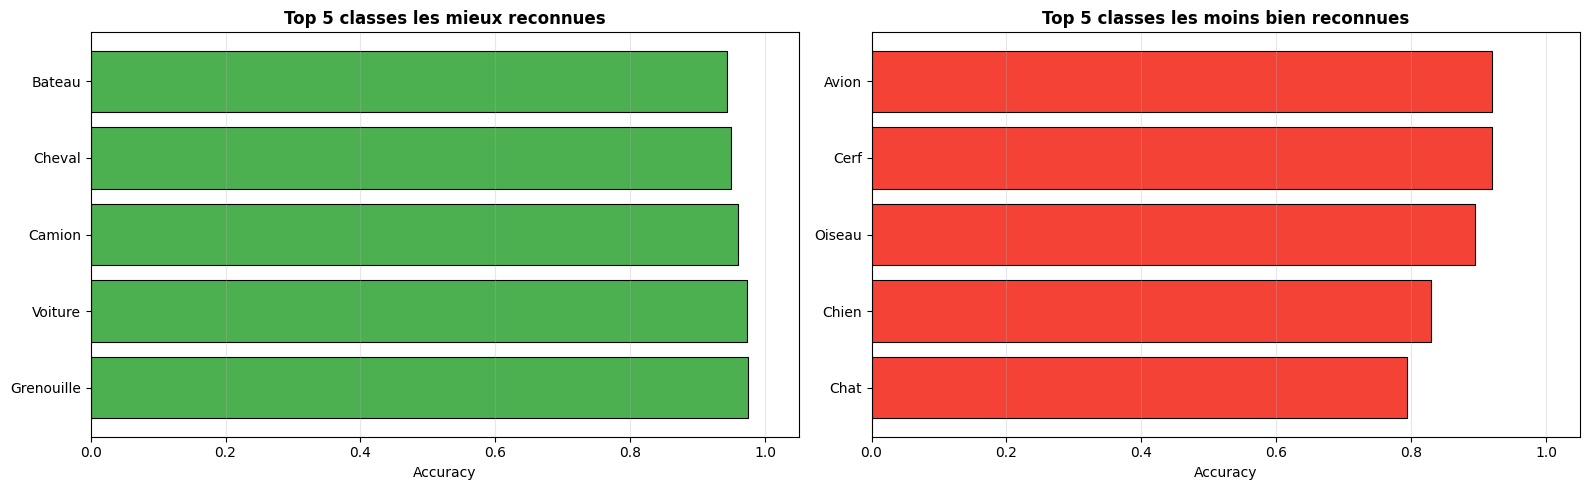

In [ ]:
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Accuracy par classe
class_acc = [np.mean(y_pred[y_test == cls] == cls)
             if (y_test == cls).sum() > 0 else np.nan
             for cls in range(NUM_CLASSES)]
class_acc_arr = np.array(class_acc)
sorted_idx    = np.argsort(class_acc_arr)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_idx = sorted_idx[-5:][::-1]
axes[0].barh([CLASS_NAMES[i] for i in top_idx], [class_acc_arr[i] for i in top_idx],
             color='#4CAF50', edgecolor='black', linewidth=0.8)
axes[0].set_title('Top 5 classes les mieux reconnues', fontweight='bold')
axes[0].set_xlabel('Accuracy'); axes[0].set_xlim(0, 1.05)
axes[0].grid(True, alpha=0.3, axis='x')

bot_idx = sorted_idx[:5]
axes[1].barh([CLASS_NAMES[i] for i in bot_idx], [class_acc_arr[i] for i in bot_idx],
             color='#F44336', edgecolor='black', linewidth=0.8)
axes[1].set_title('Top 5 classes les moins bien reconnues', fontweight='bold')
axes[1].set_xlabel('Accuracy'); axes[1].set_xlim(0, 1.05)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('accuracy_par_classe.png', dpi=100, bbox_inches='tight')
plt.show()

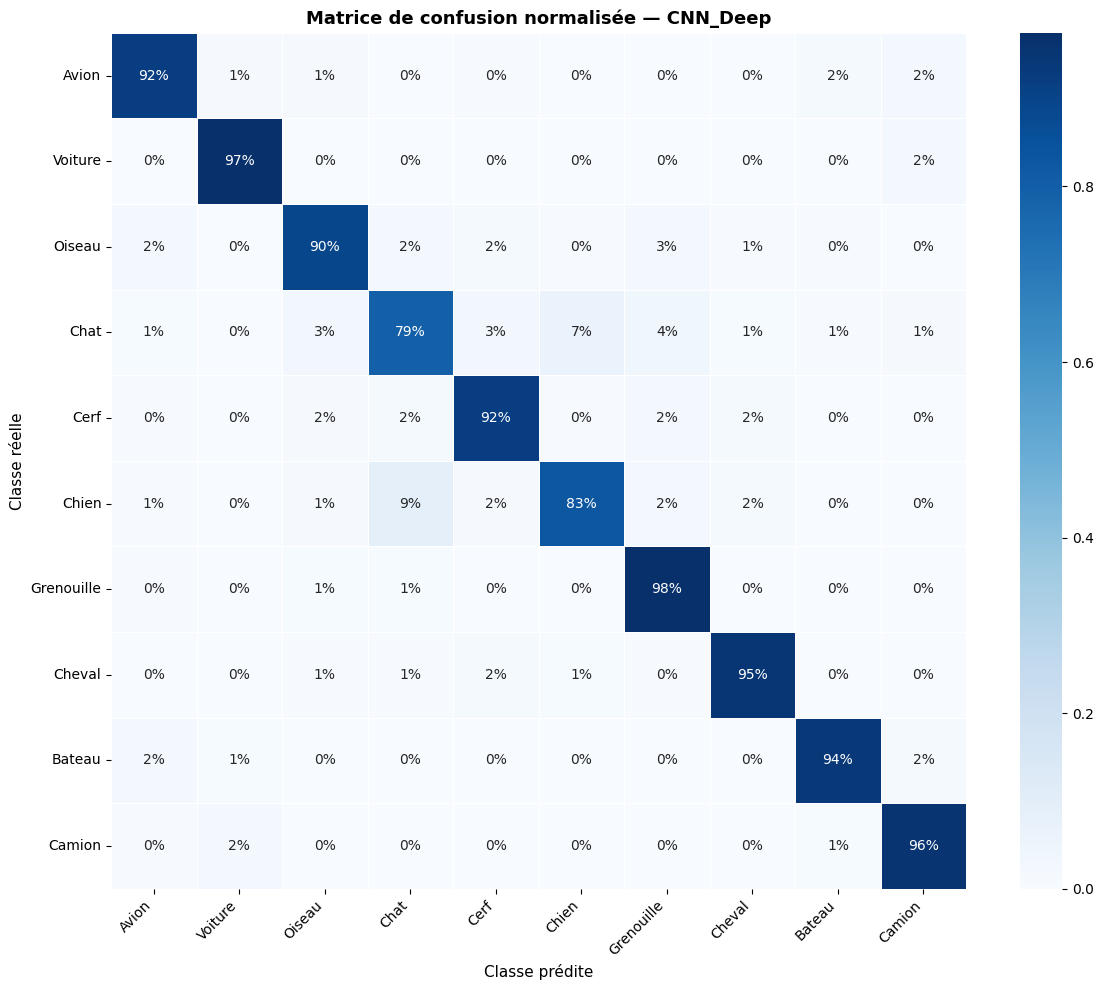

In [ ]:
# Matrice de confusion (toutes classes — CIFAR-10 n'en a que 10)
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.5)
ax.set_title(f'Matrice de confusion normalisée — {best_model_name}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Classe prédite', fontsize=11)
ax.set_ylabel('Classe réelle', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('matrice_confusion.png', dpi=100, bbox_inches='tight')
plt.show()

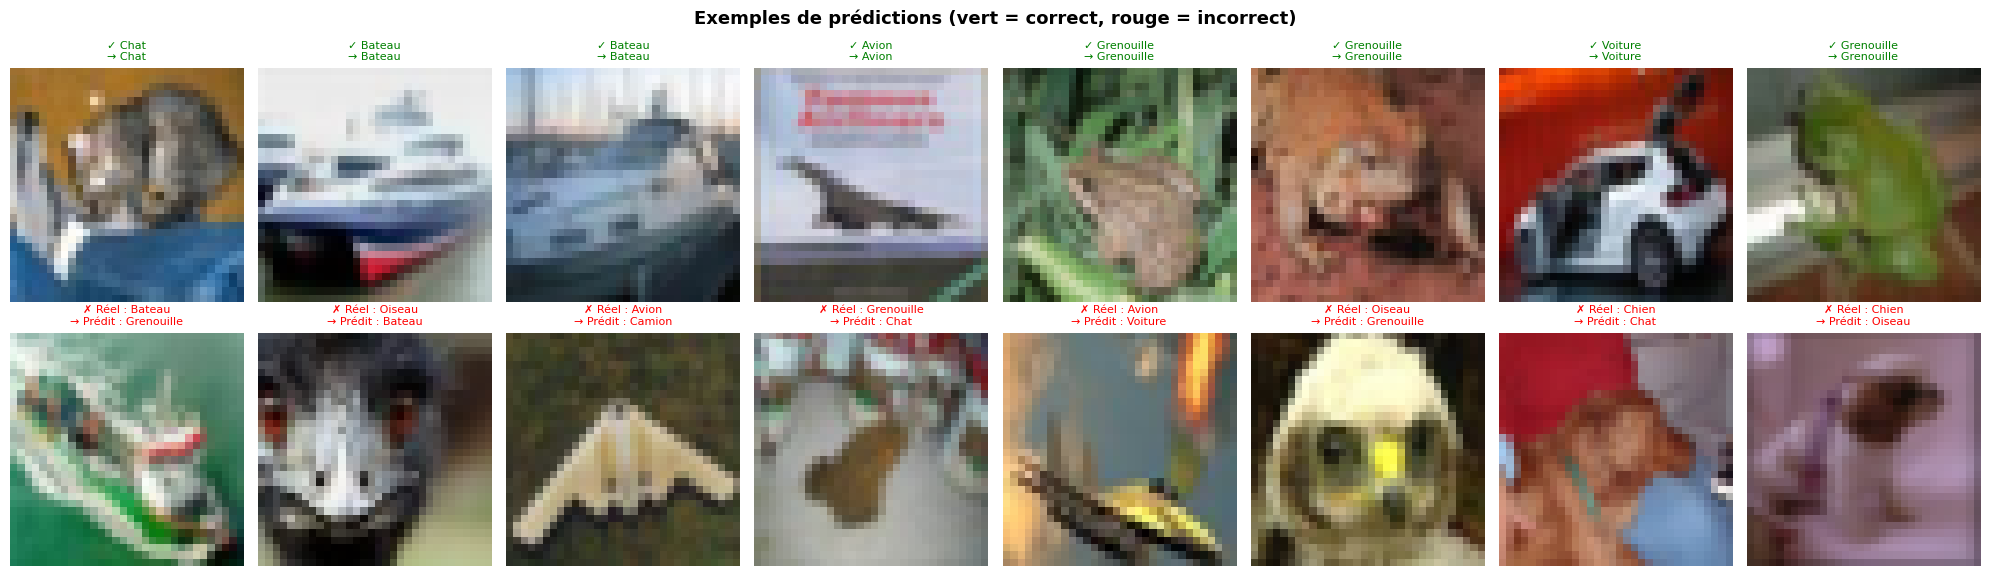

In [ ]:
# Exemples de prédictions correctes et incorrectes
correct_idx   = np.where(y_pred == y_test)[0][:8]
incorrect_idx = np.where(y_pred != y_test)[0][:8]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('Exemples de prédictions (vert = correct, rouge = incorrect)',
             fontsize=13, fontweight='bold')

for i, idx in enumerate(correct_idx):
    ax = axes[0, i]
    ax.imshow(X_test[idx])
    ax.set_title(f'✓ {CLASS_NAMES[y_test[idx]]}\n→ {CLASS_NAMES[y_pred[idx]]}',
                 fontsize=8, color='green')
    ax.axis('off')

for i, idx in enumerate(incorrect_idx):
    ax = axes[1, i]
    ax.imshow(X_test[idx])
    ax.set_title(f'✗ Réel : {CLASS_NAMES[y_test[idx]]}\n→ Prédit : {CLASS_NAMES[y_pred[idx]]}',
                 fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout()
plt.savefig('exemples_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Discussion critique

### 10.1 Comparaison des modèles

In [ ]:
print("=" * 70)
print("DISCUSSION CRITIQUE — COMPARAISON DES MODÈLES")
print("=" * 70)

for name, r in results.items():
    h           = histories[name]
    final_train = h['accuracy'][-1]
    final_val   = h['val_accuracy'][-1]
    gap         = final_train - final_val

    print(f"\n▶ {name}")
    print(f"   Test accuracy   : {r['test_acc']:.4f}")
    print(f"   Overfitting gap : {gap:.4f} (train={final_train:.4f}, val={final_val:.4f})")
    print(f"   Temps           : {r['train_time']:.1f}s")
    print(f"   Paramètres      : {r['params']:,}")

print("\n" + "=" * 70)
print(f"Meilleur modèle : {best_model_name}")
print("=" * 70)

DISCUSSION CRITIQUE — COMPARAISON DES MODÈLES

▶ CNN_Base
   Test accuracy   : 0.6553
   Overfitting gap : 0.2654 (train=0.9139, val=0.6485)
   Temps           : 70.0s
   Paramètres      : 545,098

▶ CNN_Dropout
   Test accuracy   : 0.7122
   Overfitting gap : -0.0316 (train=0.6768, val=0.7084)
   Temps           : 76.3s
   Paramètres      : 545,098

▶ CNN_Augmented
   Test accuracy   : 0.7809
   Overfitting gap : 0.0137 (train=0.7848, val=0.7711)
   Temps           : 1464.7s
   Paramètres      : 2,193,226

▶ CNN_Deep
   Test accuracy   : 0.9155
   Overfitting gap : 0.0689 (train=0.9901, val=0.9212)
   Temps           : 2676.9s
   Paramètres      : 2,802,410

Meilleur modèle : CNN_Deep


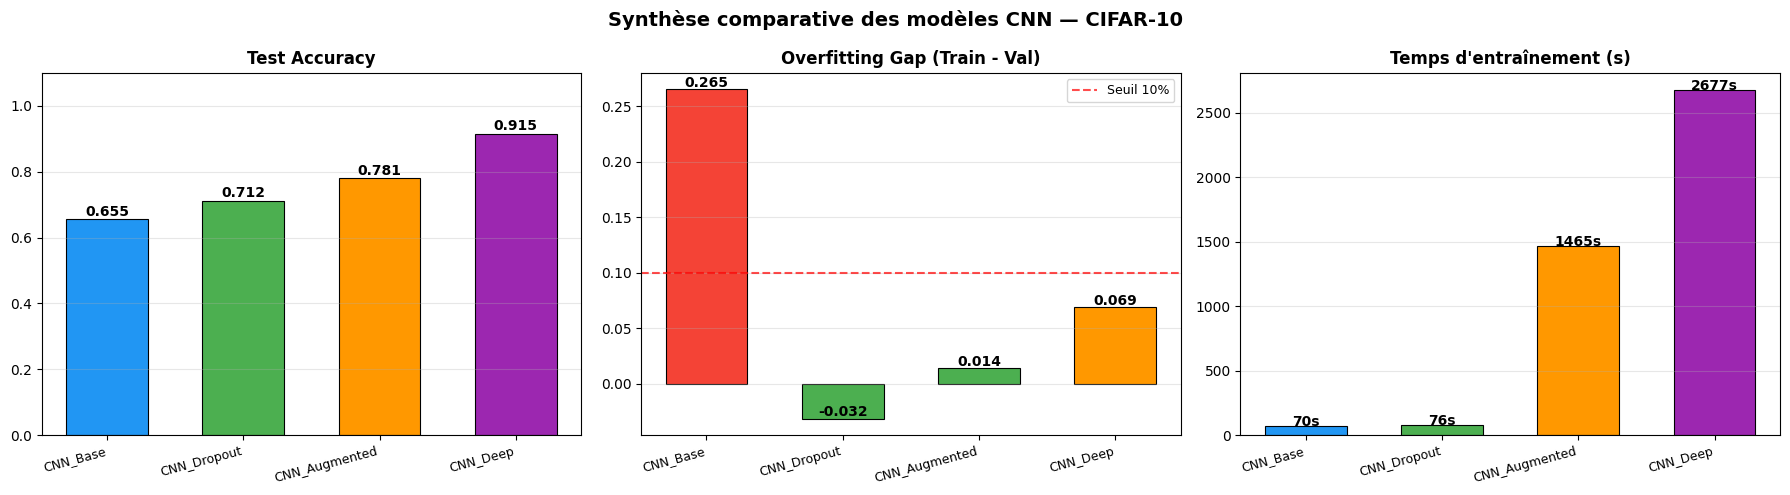

In [ ]:
# Synthèse graphique finale
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Synthèse comparative des modèles CNN — CIFAR-10', fontsize=14, fontweight='bold')

names     = list(results.keys())
test_accs = [results[n]['test_acc'] for n in names]
train_times = [results[n]['train_time'] for n in names]
overfitting_gaps = [
    histories[n]['accuracy'][-1] - histories[n]['val_accuracy'][-1]
    for n in names
]
x     = np.arange(len(names))
width = 0.6

# Test Accuracy
bars0 = axes[0].bar(x, test_accs, width, color=COLORS[:len(names)], edgecolor='black', linewidth=0.8)
axes[0].set_title('Test Accuracy', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.1)
for bar, val in zip(bars0, test_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Overfitting Gap
bar_colors_gap = ['#F44336' if g > 0.15 else '#FF9800' if g > 0.05 else '#4CAF50'
                  for g in overfitting_gaps]
bars1 = axes[1].bar(x, overfitting_gaps, width, color=bar_colors_gap, edgecolor='black', linewidth=0.8)
axes[1].set_title('Overfitting Gap (Train - Val)', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[1].axhline(y=0.1, color='red', linestyle='--', alpha=0.7, label='Seuil 10%')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, overfitting_gaps):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

# Temps d'entraînement
bars2 = axes[2].bar(x, train_times, width, color=COLORS[:len(names)], edgecolor='black', linewidth=0.8)
axes[2].set_title("Temps d'entraînement (s)", fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(names, rotation=15, ha='right', fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, train_times):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{val:.0f}s', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('synthese_comparative.png', dpi=100, bbox_inches='tight')
plt.show()

## 11. Conclusion

### Résumé des résultats

| Modèle | Rôle | Point fort | Point faible |
|---|---|---|---|
| **CNN Base** | Baseline | Rapide, simple | Overfitting élevé |
| **CNN + Dropout** | Régularisation | Réduit l'overfitting | Peut ralentir la convergence |
| **CNN + Data Aug.** | Robustesse via `ImageDataGenerator` | Améliore la généralisation | Entraînement plus long |
| **CNN Profond + ES** | Performance maximale | Meilleur compromis | Coûteux en calcul |

In [ ]:
with open('all_histories.pkl', 'wb') as f:
    pickle.dump(histories, f)

with open('all_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print("Sauvegarde finale complète :")
print("  Modèles    : cnn_base.keras, cnn_dropout.keras, cnn_augmented.keras, cnn_deep.keras")
print("  Historiques: history_cnn_base.pkl, history_cnn_dropout.pkl,")
print("               history_cnn_augmented.pkl, history_cnn_deep.pkl")
print("  Agrégés    : all_histories.pkl, all_results.pkl")
print("  Graphiques : exemples_dataset.png, distribution_classes.png,")
print("               data_augmentation_exemples.png, comparaison_modeles.png,")
print("               synthese_comparative.png, matrice_confusion.png,")
print("               accuracy_par_classe.png, exemples_predictions.png")
print("\nProjet terminé avec succès !")

Sauvegarde finale complète :
  Modèles    : cnn_base.keras, cnn_dropout.keras, cnn_augmented.keras, cnn_deep.keras
  Historiques: history_cnn_base.pkl, history_cnn_dropout.pkl,
               history_cnn_augmented.pkl, history_cnn_deep.pkl
  Agrégés    : all_histories.pkl, all_results.pkl
  Graphiques : exemples_dataset.png, distribution_classes.png,
               data_augmentation_exemples.png, comparaison_modeles.png,
               synthese_comparative.png, matrice_confusion.png,
               accuracy_par_classe.png, exemples_predictions.png

Projet terminé avec succès !
